In [ ]:
GPT_CONFIG_125M = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_rate" : 0.1,
    "qkv_bias": False
}

In [ ]:
GPT_CONFIG_125M["vocab_size"]

50257

In [ ]:
#Build a placeholder class of GPT


import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_block = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"] , cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_emb = self.tok_emb(in_idx)
    pos_emb = self.pos_emb(
        torch.arange(seq_len, device=in_idx.device)
    )
    x = tok_emb + pos_emb
    x = self.drop_emb(x)
    x = self.trf_block(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


class DummyTransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()

  def forward(self, x):
    return x

class DummyLayerNorm(nn.Module):
  def __init__(self, normalized_shape, epd=1e-5):
    super().__init__()

  def forward(self, x):
    return x



In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


text -> tokenized text -> Token IDs -> token embeddings (768 dim) -> GPT Model -> Outputs(768 dim) -> Postprocessing steps -> output text


"For the smallest GPT-2 model,
each embedding vector consists
of 768 dimensions (only the first
2 dimensions are shown)."

In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_125M)
logits = model(batch)

print("Output Shape: " , logits.shape)
print(logits)

Output Shape:  torch.Size([2, 4, 50257])
tensor([[[-1.4271, -0.2840,  1.5161,  ...,  0.7439, -0.6418,  0.4433],
         [-0.2276, -2.2575, -1.9347,  ...,  0.2742, -0.9795,  1.7535],
         [ 0.9470, -1.8268, -1.0140,  ..., -0.3285,  1.5704,  0.2225],
         [ 0.3692,  1.1697, -0.4005,  ..., -0.1971, -0.4948,  0.4396]],

        [[-0.7591, -1.3767,  1.9161,  ...,  0.8532,  0.2496,  0.9997],
         [ 0.2858, -1.2932, -1.5919,  ...,  0.8678, -0.5365,  2.1935],
         [ 1.5425, -0.5500, -0.6527,  ..., -0.6807, -0.3069,  0.0805],
         [ 1.1016,  0.7336,  0.2600,  ..., -0.2363, -0.4450,  0.5277]]],
       grad_fn=<UnsafeViewBackward0>)


# 4.2 Normalizing activations with layer normalization

In [ ]:

torch.manual_seed(123)
batch_example = torch.rand(2,5) #Creates two training examples with five dimensions (features) each
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)

print(f"batch_example:\n{batch_example}")
print(f"layer:\n{layer[0].weight}")
print(f"out:\n{out}")

batch_example:
tensor([[0.2961, 0.5166, 0.2517, 0.6886, 0.0740],
        [0.8665, 0.1366, 0.1025, 0.1841, 0.7264]])
layer:
Parameter containing:
tensor([[-0.1652,  0.1674, -0.3796, -0.2713, -0.1642],
        [-0.0879, -0.3412,  0.2928, -0.1055,  0.1436],
        [ 0.3162,  0.0833,  0.1223,  0.4317, -0.2017],
        [ 0.1417, -0.1990,  0.3196,  0.3572, -0.4123],
        [ 0.3818,  0.2136,  0.1949,  0.1841,  0.3718],
        [-0.0590, -0.3782, -0.1283, -0.3150,  0.0296]], requires_grad=True)
out:
tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
#examine the mean and variance

mean = out.mean(dim=-1, keepdim=True) #dim=-1 to keep the same dim as  [batch_size, num_tokens, embedding_size]
var = out.var(dim=-1, keepdim=True)

print(f"Mean:\n{mean}")
print(f"var:\n{var}")


Mean:
tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)
var:
tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)


In [ ]:
out_norm = (out - mean) /torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True) #dim=-1 to keep the same dim as  [batch_size, num_tokens, embedding_size]
var = out_norm.var(dim=-1, keepdim=True)

print(f"Normalized Outputs:\n{out_norm}")
print(f"Mean:\n{mean}")
print(f"var:\n{var}")

Normalized Outputs:
tensor([[-0.8603, -0.8603,  0.5869,  1.4698,  0.5242, -0.8603],
        [-0.7450, -0.7450, -0.0102,  0.4844,  1.7608, -0.7450]],
       grad_fn=<DivBackward0>)
Mean:
tensor([[ 5.9605e-08],
        [-4.9671e-08]], grad_fn=<MeanBackward1>)
var:
tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [ ]:
# Note that the value –5.9605e-08 in the output tensor is the scientific notation for–5.9605 × 10-8, which is –0.000000059605 in decimal form. This value is very close to 0,
# but it is not exactly 0 due to small numerical errors that can accumulate because of
# the finite precision with which computers represent numbers.

torch.set_printoptions(sci_mode=False)
print(f"Mean:\n{mean}")
print(f"var:\n{var}")

Mean:
tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
var:
tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim =-1, keepdim=True)
    var = x.var(dim =-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)

    return self.scale * norm_x + self.shift

In [ ]:
# Let’s now try the LayerNorm module in practice and apply it to the batch input:

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True)
print(f"Mean:\n{mean}")
print(f"Var:\n{var}")

Mean:
tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Var:
tensor([[1.2497],
        [1.2499]], grad_fn=<VarBackward0>)


Layer normalization vs. batch normalization
If you are familiar with batch normalization, a common and traditional normalization
method for neural networks, you may wonder how it compares to layer normalization.
Unlike batch normalization, which normalizes across the batch dimension, layer nor
malization normalizes across the feature dimension. LLMs often require significant
computational resources, and the available hardware or the specific use case can
dictate the batch size during training or inference. Since layer normalization normal
izes each input independently of the batch size, it offers more flexibility and stability
in these scenarios. This is particularly beneficial for distributed training or when
deploying models in environments where resources are constrained.

# 4.3 Implementing a feed forward network with GELU activations

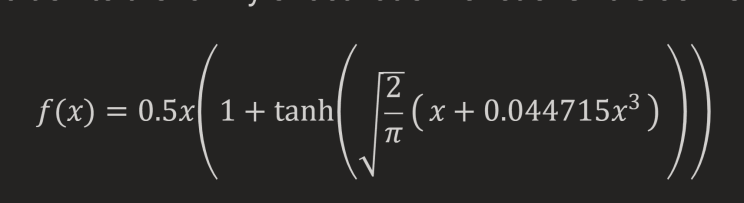

In [ ]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * ( 1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * ( x + 0.044715 * torch.pow(x,3))
        ))

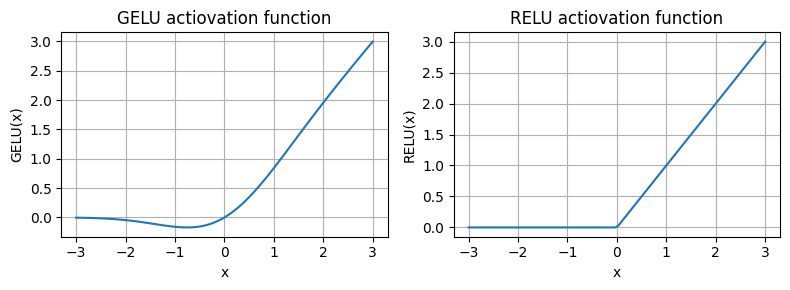

In [ ]:
#Get an idea of what the gelu looks like

import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3,3,100) # create 100 sample data points in the range -3 to 3
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]),1):
  plt.subplot(1,2,i)
  plt.plot(x,y)
  plt.title(f"{label} actiovation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# let’s use the GELU function to implement the small neural network module,
# FeedForward, that we will be using in the LLM’s transformer block later.

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
ffn = FeedForward(GPT_CONFIG_125M)
x = torch.rand(2,3,768) # Batch:2, Num_Tokens:3, Embeddings_Dim:768
out = ffn(x)
print(x.shape)
print(out.shape)

torch.Size([2, 3, 768])
torch.Size([2, 3, 768])


In [ ]:
print(ffn.layers[0].weight.shape)
print(ffn.layers[2].weight.shape)

torch.Size([3072, 768])
torch.Size([768, 3072])


# 4.4 Adding shortcut connections

In [ ]:
# A neural network to illustrate shortcut connections

class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self, layer_sizes, use_shortcut):
    super().__init__()
    self.use_shortcut = use_shortcut
    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),

    ])

  def forward(self, x):
    for layer in self.layers:
      layer_output = layer(x)
      if self.use_shortcut and x.shape == layer_output.shape:
        x = x + layer_output
      else:
        x = layer_output

    return x

In [ ]:
#without skip connections

layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1., 0., -1.]]) #specifies random seed for the initial weights for reproducibility
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [ ]:
#we implement a function that computes the gradients in the model’s backward pass:
def print_gradients(model, x):
  # Clear any existing gradients
  for param in model.parameters():
      param.grad = None
  output = model(x) #Forward Pass
  target = torch.tensor([[0.]])

  loss = nn.MSELoss()
  loss_value = loss(output,target) #Calculate loss based on how close the target and the output are

  loss_value.backward() # backward pass to calculate the gradients

  for name, param in model.named_parameters():
    if 'weight' in name:
      if param.grad is not None:
                print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")
      else:
          print(f"{name} has no gradient")




In [ ]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [ ]:
# Now model with skip connections:

torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

print_gradients(model_with_shortcut, sample_input)
#From the output we can see the backward gradients (from 4 to 1 layer) are not very small.
#Hence, the skip connections actually help with the vanishing gradients problem.

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


## 4.5 Connecting attention and linear layers in a transformer blocl

In [ ]:
# MultiHeadAttention Block from Ch02:

class MultiHeadAttention(nn.Module):
  def __init__( self, d_in,d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), \
         "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads #Reduces the projection dim to match the desired output dim

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.out_proj = nn.Linear(d_out,d_out) # uses a linear layer to combine head outputs

    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length),
                   diagonal = 1)
    )

  def forward(self,x):
    b, num_tokens, d_in = x.shape

    keys = self.W_key(x) # Tensor shape: (b, num_tokens, d_out)
    queries = self.W_query(x) # Tensor shape: (b, num_tokens, d_out)
    values = self.W_value(x) # Tensor shape: (b, num_tokens, d_out)

    # We implicitly split the matrixby adding the num_heads dimension
    # Then we unroll the last dim: (b,num_tokens,dout) -> (b,num_tokens, num_heads, head_dims)
    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)

    #Transpose (b, num_tokens, num_heads, head_dims)-> (b, num_heads, num_tokens, head_dims)
    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    #compute dot products for each head
    attn_scores = queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens] # mask turncated to the number of tokens

    attn_scores.masked_fill_(mask_bool, -torch.inf) #used the mask to fill atention scores

    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1] ** 0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2) # Tensor shape: (b,num_tokens,n_heads,head_dim)

    context_vec = context_vec.contiguous().view( #combines heads where self.dout = self.num_heads * self.head_dim
        b,num_tokens,self.d_out
    )
    context_vec = self.out_proj(context_vec) # adds an optional linear projection

    return context_vec


In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_length"],
        num_heads= cfg["n_heads"],
        dropout = cfg["drop_rate"],
        qkv_bias= cfg["qkv_bias"]

    )

    self.ff = FeedForward(cfg)

    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    shortcut = x

    x = self.norm1(x)
    x = self.att(x)
    x = self.dropout_shortcut(x)

    x = x + shortcut #shortcut connection with the first/input

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout_shortcut(x)

    x = x + shortcut

    return x

In [ ]:
torch.manual_seed(123)

x = torch.rand(2,4,768)
block = TransformerBlock(GPT_CONFIG_125M)
output = block(x)


print(f"Input Size: {x.shape}")
print(f"Output Size: {output.shape}")


Input Size: torch.Size([2, 4, 768])
Output Size: torch.Size([2, 4, 768])


## Coding the GPT Model




In [ ]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):

    batch, seq_len = in_idx.shape

    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
        torch.arange(seq_len, device=in_idx.device)) #The device setting will allow us to train the model on CPU or GPU, depending on which device the input data sits on

    x = tok_embeds + pos_embeds

    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)

    return logits

In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_125M)

out = model(batch)

print(f"Input shape:\n{batch.shape}")
print(f"Input:\n{batch}")
print(f"Output shape:\n{out.shape}")
print(f"Output:\n{out}")


Input shape:
torch.Size([2, 4])
Input:
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape:
torch.Size([2, 4, 50257])
Output:
tensor([[[-0.4041,  0.1929,  0.6352,  ...,  1.0106,  0.0980, -0.7053],
         [ 0.5707,  0.0544, -0.2771,  ...,  0.5032,  0.2747, -0.8917],
         [-0.8907, -0.0139,  0.2601,  ..., -0.6708, -0.1150, -0.1822],
         [-0.2134,  0.5401,  0.6125,  ...,  0.2379, -1.0108, -0.5932]],

        [[ 0.0905,  0.2988,  0.2590,  ...,  1.2425,  0.0028, -0.8081],
         [ 0.5151,  0.2019,  0.0132,  ...,  0.7170,  0.6213, -0.1541],
         [ 0.0864,  0.0160,  0.2285,  ..., -0.1427, -0.4817,  0.1165],
         [ 0.6992,  0.8022,  0.4686,  ...,  1.1546, -1.1988, -0.8110]]],
       grad_fn=<UnsafeViewBackward0>)


In [ ]:
#calculating the parameters in the model now

total_params = sum(p.numel() for p in model.parameters())
print(f"Total Number of Parameters: {total_params}")

Total Number of Parameters: 200820480


In [ ]:
#Weight tying: GPT-2 reuses the weights from token embedding layer in its output layer
print("Token embedding layer shape: ", model.tok_emb.weight.shape)
print(f"Output layer shape        : {model.out_head.weight.shape}")

Token embedding layer shape:  torch.Size([50257, 768])
Output layer shape        : torch.Size([50257, 768])


In [ ]:
total_params_gpt2 = (
    total_params - sum(p.numel() for p in model.out_head.parameters())
)

print(f"Number of trainable parameters "
f"Considering weight tying: {total_params_gpt2}")

Number of trainable parameters Considering weight tying: 162223104


In [ ]:
#Total memory foot print

total_size_bytes = total_params * 4 # All params with FP32
total_size_mb = total_size_bytes / (1024 * 1024) # converting to MBs
print(f"Total Size in MBs: {total_size_mb}")

Total Size in MBs: 766.0693359375


# 4.8 A function for the GPT model to generate text

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  #idx is a (batch, n_tokens) array of indices in the current context
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:] # Crops current context if it exceeds the supported context size, only last tokens (of context size) are used
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:,-1,:] #focues only on the last time step, so that (batch, n_tokens, vocab_size) becomes (batch,n_tokens)
    probas = torch.softmax(logits, dim=-1) #probas has shape (batch, vocab_size)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) # idx_next has shape (batch, 1) 'one max value'
    idx = torch.cat((idx, idx_next), dim=-1) #append the sampled index to the running sequence, where idx has shape (batch, n_tokens+1)

  return idx


In [ ]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0) #Adds batch dimenstion
print("encoded_tensor.shape: ", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape:  torch.Size([1, 4])


In [ ]:
model.eval()
out = generate_text_simple(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size = GPT_CONFIG_125M["context_length"]
)
print(f"output:\n{out}")
print(f"output shape:\n{out.shape}")

output:
tensor([[15496,    11,   314,   716, 15851,  4029, 45838, 37045, 44119,  4933]])
output shape:
torch.Size([1, 10])


In [ ]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(f"decoded output:\n{decoded_text}")

decoded output:
Hello, I am eternalml PLAATIVE premieredUp
